In [1]:
#Import packages 

import numpy as np 
import pandas as pd 
import json 
import glob
import os
import csv
from statsmodels.tsa.seasonal import seasonal_decompose

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc
from pathlib import Path
import warnings

In [2]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)

In [3]:
warnings.filterwarnings('ignore', category=FutureWarning)

In [4]:
# =====================================================
# Detailed season classification
# =====================================================

def assign_season(month):
    if month in [12, 1, 2, 3]:
        return 'Dry_Season'
    elif month in [4, 5, 6, 7]:
        return 'Major_Rainy_Season'
    elif month in [9, 10, 11]:
        return 'Minor_Rainy_Season'
    else:
        return 'Transition_Season'


# =====================================================
# Simpler season classification
# =====================================================

def assign_simple_season(month):
    if month in [12, 1, 2, 3]:
        return 'Dry_Season'
    elif month in [4, 5, 6, 7, 9, 10, 11]:
        return 'Rainy_Season'
    else:
        return 'Transition_Season'

### Sensor - CESI Mapping 

### using `rev1` version --> (2 CESI clusters instead of 3)  

In [5]:
### CESI Mapping here 
sensor_cesi_mapping = pd.read_csv(DATA_DIR / 'miscellaneous/sensor_cesi_mapping_rev1.csv').drop(columns=['Unnamed: 0'])

## *** Reading processed hourly data 

### `2022` & `2023` + `concat` 

In [37]:
processed_hourly_voltage_df_22 = pd.read_csv(DATA_DIR / 'processed_undervolt_data/undervolt_hourly_voltages_df_22.csv')

processed_hourly_voltage_df_23 = pd.read_csv(DATA_DIR / 'processed_undervolt_data/undervolt_hourly_voltages_df_23.csv')

combined_hourly_voltage_df = pd.concat([processed_hourly_voltage_df_22, processed_hourly_voltage_df_23], ignore_index=True)

### keep only sensors of interest 

In [38]:
sensor_of_interest_list = pd.read_csv(DATA_DIR / 'miscellaneous/common_sensors_22_23_rev4.csv')['respondent_id'].unique().tolist()

combined_hourly_voltage_df = combined_hourly_voltage_df[combined_hourly_voltage_df['sensor_id'].isin(sensor_of_interest_list)].reset_index(drop=True)

## add CESI mapping 
combined_hourly_voltage_df = combined_hourly_voltage_df.merge(sensor_cesi_mapping, on = 'sensor_id')

### *** Reading hourly temp data 

In [8]:
hourly_temperature = pd.read_csv(DATA_DIR / 'miscellaneous/hourly_temp_sites_of_interest.csv').drop(columns = ['Unnamed: 0'])

### *** Merging with voltage data 

In [42]:
combined_hourly_voltage_df = combined_hourly_voltage_df.merge(hourly_temperature, on = ['time', 'site_id'])

combined_hourly_voltage_df = combined_hourly_voltage_df[['time', 'ea_code9ch',  'site_id', 'sensor_id', 'voltage', 'Temp', 'cesi_level']]

### Add season 

In [43]:
# Make sure time is datetime
combined_hourly_voltage_df['time'] = pd.to_datetime(
    combined_hourly_voltage_df['time']
)

# Extract month
combined_hourly_voltage_df['Month'] = (
    combined_hourly_voltage_df['time'].dt.month
)

# =====================================================
# Detailed season classification
# =====================================================

combined_hourly_voltage_df['season_detailed'] = (
    combined_hourly_voltage_df['Month']
    .apply(assign_season)
)

# =====================================================
# Simpler season classification
# =====================================================

combined_hourly_voltage_df['season_simple'] = (
    combined_hourly_voltage_df['Month']
    .apply(assign_simple_season)
)

In [44]:
combined_hourly_voltage_df.head()

,time,ea_code9ch,site_id,sensor_id,voltage,Temp,cesi_level,Month,season_detailed,season_simple
0,2022-01-01 00:00:00,30410207,1,bb3ff846,236.64,26.220942,Low,1,Dry_Season,Dry_Season
1,2022-01-01 01:00:00,30410207,1,bb3ff846,235.38,26.099647,Low,1,Dry_Season,Dry_Season
2,2022-01-01 02:00:00,30410207,1,bb3ff846,235.45,25.953452,Low,1,Dry_Season,Dry_Season
3,2022-01-01 03:00:00,30410207,1,bb3ff846,236.54,25.779780,Low,1,Dry_Season,Dry_Season
4,2022-01-01 04:00:00,30410207,1,bb3ff846,237.72,25.564437,Low,1,Dry_Season,Dry_Season


## Scatter plots 

In [68]:
def plot_voltage_vs_weather(
    df,
    weather_col,
    x_label,
    title=None,
    sample_size=100_000,
):
    """
    Plot voltage against a weather variable with a linear regression line.

    Regression statistics are calculated using all valid observations.
    A sample is used only for the scatter plot visualization.
    """

    # Keep only complete voltage-weather pairs
    plot_df = df[["voltage", weather_col]].dropna()

    # Linear regression using all observations
    slope, intercept, r_value, p_value, std_err = linregress(
        plot_df[weather_col],
        plot_df["voltage"]
    )

    r_squared = r_value**2

    # Print summary
    print(f"Variable: {weather_col}")
    print(f"R = {r_value:.4f}")
    print(f"R² = {r_squared:.4f}")
    print(f"Slope = {slope:.4f}")
    print(f"p-value = {p_value:.4e}")
    print(f"N = {len(plot_df):,}")

    # Regression line
    x_line = np.linspace(
        plot_df[weather_col].min(),
        plot_df[weather_col].max(),
        100
    )
    y_line = intercept + slope * x_line

    # Sample only for visualization
    scatter_df = plot_df.sample(
        n=min(sample_size, len(plot_df)),
        random_state=42
    )

    # Plot
    plt.figure(figsize=(8, 6))

    plt.scatter(
        scatter_df[weather_col],
        scatter_df["voltage"],
        alpha=0.1,
        s=5
    )

    plt.plot(
        x_line,
        y_line,
        linewidth=2,
        label=f"Linear fit (R = {r_value:.3f}, R² = {r_squared:.3f})"
    )

    plt.xlabel(x_label)
    plt.ylabel("Voltage (V)")
    plt.title(title or f"Voltage vs. {weather_col}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Return results so they can be saved/compared later
    return {
        "variable": weather_col,
        "R": r_value,
        "R_squared": r_squared,
        "slope": slope,
        "p_value": p_value,
        "N": len(plot_df)
    }

### Temperature 

Variable: Temp
R = -0.2010
R² = 0.0404
Slope = -1.4176
p-value = 0.0000e+00
N = 6,135,649


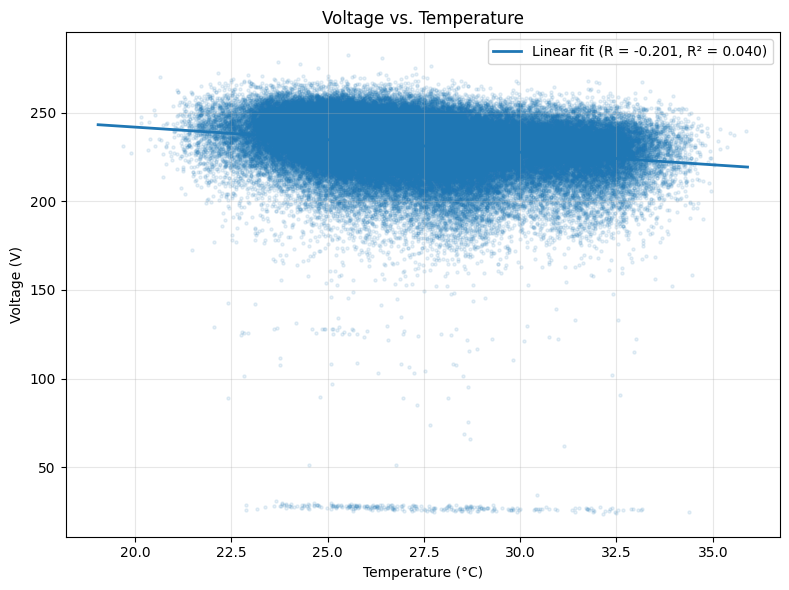

In [69]:
temp_results = plot_voltage_vs_weather(
    df=combined_hourly_voltage_df,
    weather_col="Temp",
    x_label="Temperature (°C)",
    title="Voltage vs. Temperature"
)

### Precipitation 

In [70]:
voltage_df = combined_hourly_voltage_df[
    ["time", "ea_code9ch", "sensor_id", "voltage"]
].copy()

precip_df = (pd.read_csv("../files/processed_weather_data/precip_all_years_6km_buffer.csv").drop(columns=["Unnamed: 0"], errors="ignore"))
precip_df["time"] = pd.to_datetime(precip_df["time"])

precip_n_volts = voltage_df.merge(
    precip_df,
    on=["time", "ea_code9ch"]
)

Variable: Precip
R = 0.0167
R² = 0.0003
Slope = 0.2211
p-value = 0.0000e+00
N = 6,135,649


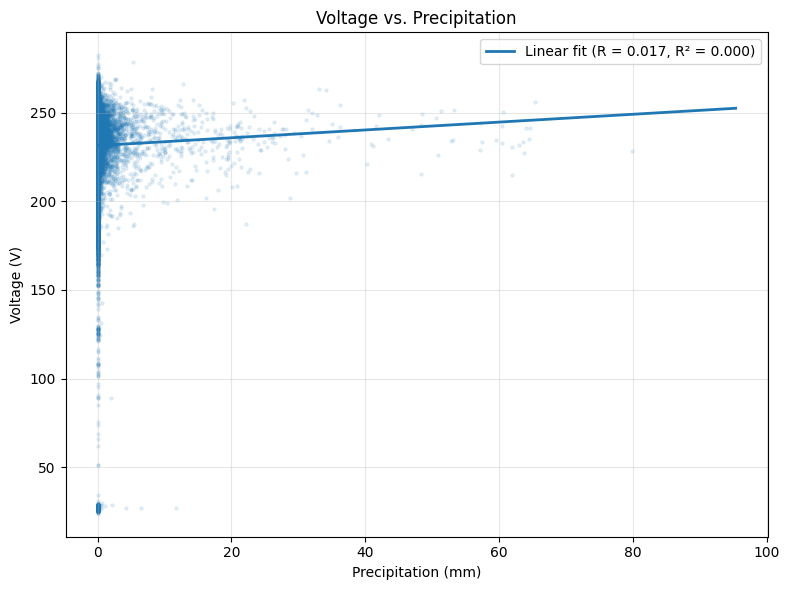

In [71]:
precip_results = plot_voltage_vs_weather(
    df=precip_n_volts,
    weather_col="Precip",
    x_label="Precipitation (mm)",
    title="Voltage vs. Precipitation"
)

### Wind 

In [78]:
wind_df = (
    pd.read_csv(
        "../files/processed_weather_data/ea_hourly_wind_avg_6km.csv"
    ).drop(columns=["Unnamed: 0"], errors="ignore").rename(columns={"Timestamp": "time"}))

wind_df["time"] = pd.to_datetime(wind_df["time"])

wind_n_volts = voltage_df.merge(
    wind_df,
    on=["time", "ea_code9ch"]
)

Variable: Wind Gusts (m/s)
R = -0.0673
R² = 0.0045
Slope = -0.8323
p-value = 0.0000e+00
N = 6,135,649


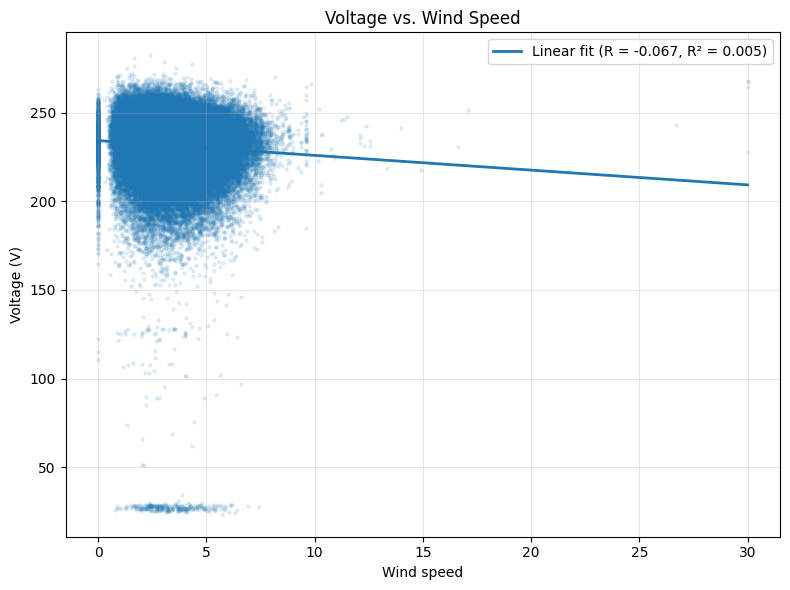

In [82]:
wind_results = plot_voltage_vs_weather(
    df=wind_n_volts,
    weather_col="Wind Gusts (m/s)",
    x_label="Wind speed",
    title="Voltage vs. Wind Speed"
)

### Lightning 

In [83]:
lightning_df = (
    pd.read_csv(
        "../files/processed_weather_data/ea_hourly_lightning_avg_6km_buffer_aligned.csv"
    ).drop(columns=["Unnamed: 0"], errors="ignore").rename(columns={"Timestamp": "time"}))

lightning_df["time"] = pd.to_datetime(lightning_df["time"])

lightning_n_volts = voltage_df.merge(
    lightning_df,
    on=["time", "ea_code9ch"]
)

Variable: Lightning Events
R = 0.0052
R² = 0.0000
Slope = 0.0426
p-value = 2.8183e-35
N = 5,602,292


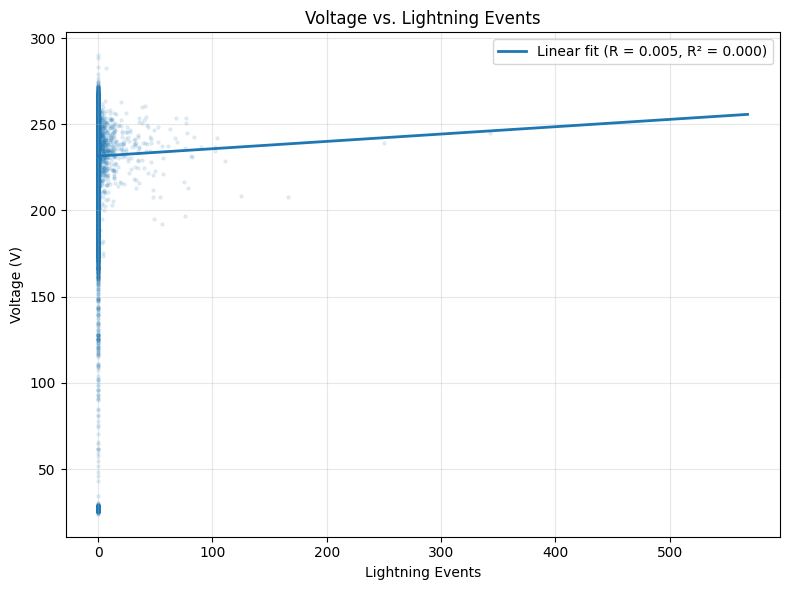

In [85]:
lightning_results = plot_voltage_vs_weather(
    df=lightning_n_volts,
    weather_col="Lightning Events",
    x_label="Lightning Events",
    title="Voltage vs. Lightning Events"
)

### All Results 

In [87]:
results_df = pd.DataFrame([
    temp_results,
    precip_results,
    wind_results,
    lightning_results
])

In [88]:
results_df

,variable,R,R_squared,slope,p_value,N
0,Temp,-0.200980,0.040393,-1.417610,0.000000e+00,6135649
1,Precip,0.016712,0.000279,0.221098,0.000000e+00,6135649
2,Wind Gusts (m/s),-0.067311,0.004531,-0.832330,0.000000e+00,6135649
3,Lightning Events,0.005236,0.000027,0.042571,2.818307e-35,5602292


### Results for Supplementary Table 

In [92]:
results_display = results_df.copy().drop(columns=['p_value', 'N'])

results_display["R"] = results_display["R"].round(4)
results_display["R_squared"] = results_display["R_squared"].round(4)
results_display["slope"] = results_display["slope"].round(4)

results_display

,variable,R,R_squared,slope
0,Temp,-0.2010,0.0404,-1.4176
1,Precip,0.0167,0.0003,0.2211
2,Wind Gusts (m/s),-0.0673,0.0045,-0.8323
3,Lightning Events,0.0052,0.0000,0.0426


In [105]:
combined_hourly_voltage_df.dropna()['ea_code9ch'].nunique()

201

In [103]:
precip_n_volts.dropna()['ea_code9ch'].nunique()

201

In [102]:
wind_n_volts.dropna()['ea_code9ch'].nunique()

201

In [106]:
lightning_n_volts.dropna()['ea_code9ch'].nunique()

181